# Image Classification — Beginner's Guide with PyTorch
## Intel Image Classification Dataset

---

### What is Image Classification?

Image classification is the task of looking at an image and deciding which category it belongs to. When you upload a photo to Google Photos and it recognises it as a beach, that is image classification.

In this notebook, we build a complete image classification system from scratch — from loading raw images all the way to evaluating predictions. We use the **Intel Image Classification** dataset, which contains natural scene photos across 6 categories:

- **Buildings** — cityscapes, architecture
- **Forest** — trees, nature
- **Glacier** — ice fields, arctic
- **Mountain** — peaks, highlands
- **Sea** — ocean, coastline
- **Street** — roads, urban scenes

This is a more realistic and visually interesting challenge than MNIST. The categories share visual features (mountains and glaciers both have rocks; forests and streets both have vertical structures) which makes it genuinely hard.

---

### What You Will Learn

1. How to set up a dataset for PyTorch using `ImageFolder`
2. What exploratory data analysis (EDA) looks like for image data
3. How a CNN processes an image — layer by layer
4. How to write a clean, reusable training loop
5. How to read training curves and spot problems
6. How to evaluate a model properly — beyond just accuracy

---

### Dataset Setup on Kaggle

This notebook uses the **Intel Image Classification** dataset available on Kaggle.
Add it to your notebook via: `+ Add Data` → search `intel image classification` → select the dataset by puneet-bansal.

Expected folder structure after adding:
```
/kaggle/input/intel-image-classification/
    seg_train/seg_train/
        buildings/, forest/, glacier/, mountain/, sea/, street/
    seg_test/seg_test/
        buildings/, forest/, glacier/, mountain/, sea/, street/
    seg_pred/seg_pred/
```

---
## Section 1 — Imports and Configuration

We begin by importing everything we need and defining the key settings in one place. Keeping all configuration at the top (instead of scattered through the notebook) makes it easy to experiment — change `EPOCHS` or `BATCH_SIZE` once and it applies everywhere.

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ──────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Paths ────────────────────────────────────────────────────────
BASE_DIR   = Path('/kaggle/input/datasets/blourdhuraju/intel-image-classification-dataset/Intel-Image-Classification')
TRAIN_DIR  = BASE_DIR / 'train'
TEST_DIR   = BASE_DIR / 'test'

# ── Hyperparameters ──────────────────────────────────────────────
IMG_SIZE   = 64        # resize all images to 64x64
BATCH_SIZE = 64
EPOCHS     = 15
LR         = 1e-3
NUM_CLASSES = 6

CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
# Distinct colours for each class — used consistently in all plots
CLASS_COLORS = ['#E53935', '#43A047', '#1E88E5', '#8E24AA', '#00ACC1', '#FB8C00']

print(f'Device         : {DEVICE}')
print(f'Image size     : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size     : {BATCH_SIZE}')
print(f'Epochs         : {EPOCHS}')
print(f'Classes        : {CLASS_NAMES}')
print(f'Train dir exists: {TRAIN_DIR.exists()}')
print(f'Test dir exists : {TEST_DIR.exists()}')

Device         : cuda
Image size     : 64x64
Batch size     : 64
Epochs         : 15
Classes        : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train dir exists: True
Test dir exists : True


---
## Section 2 — Exploratory Data Analysis (EDA)

Before training anything, we explore the dataset. This step is skipped by beginners but it is one of the most important habits in data science. EDA answers:

- How many images do we have per class? (class imbalance?)
- What do the images actually look like?
- What is the typical image size?

These answers directly inform how we design our model and whether we need special handling (e.g. weighted loss for imbalanced classes).

In [3]:
# Count images per class in train and test splits
train_counts = {}
test_counts  = {}

for cls in CLASS_NAMES:
    train_path = TRAIN_DIR / cls
    test_path  = TEST_DIR  / cls
    train_counts[cls] = len(list(train_path.glob('*.jpg'))) if train_path.exists() else 0
    test_counts[cls]  = len(list(test_path.glob('*.jpg')))  if test_path.exists()  else 0

total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())

print('Class distribution:')
print(f'{"Class":<12} {"Train":>7} {"Test":>6} {"Train%":>8}')
print('-' * 36)
for cls in CLASS_NAMES:
    pct = train_counts[cls] / total_train * 100
    print(f'{cls:<12} {train_counts[cls]:>7,} {test_counts[cls]:>6,} {pct:>7.1f}%')
print('-' * 36)
print(f'{"TOTAL":<12} {total_train:>7,} {total_test:>6,}')

Class distribution:
Class          Train   Test   Train%
------------------------------------
buildings      1,972    437    15.6%
forest         2,044    474    16.2%
glacier        2,164    553    17.1%
mountain       2,261    525    17.9%
sea            2,047    510    16.2%
street         2,144    501    17.0%
------------------------------------
TOTAL         12,632  3,000


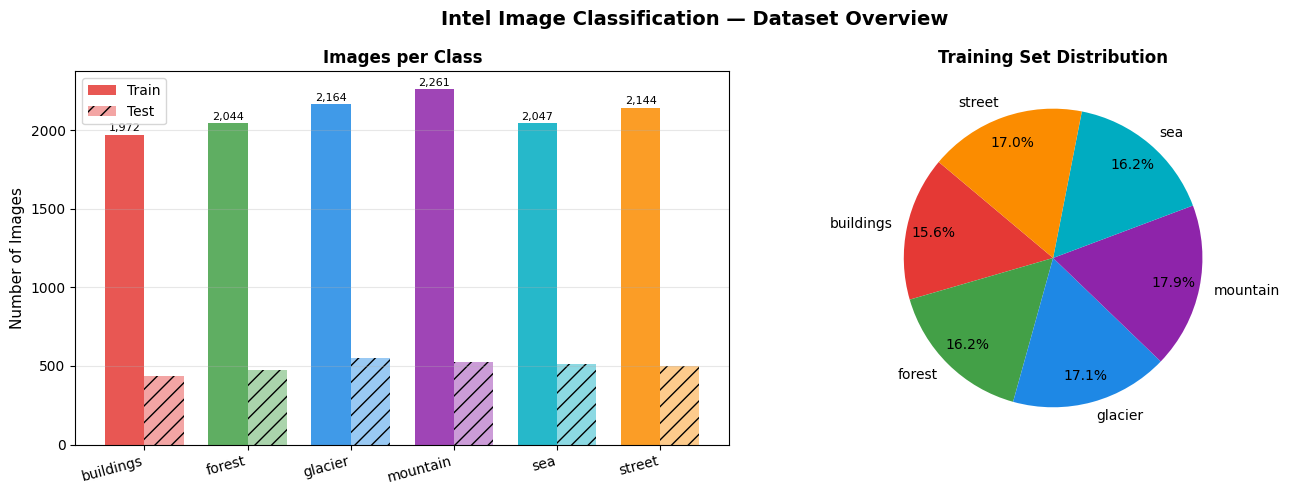

Class imbalance ratio (max/min): 1.15x
Note: ratio < 2x is generally acceptable without special handling.


In [4]:
# Visualise class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
x = np.arange(len(CLASS_NAMES))
w = 0.38
b1 = ax1.bar(x - w/2, [train_counts[c] for c in CLASS_NAMES],
             w, color=CLASS_COLORS, alpha=0.85, label='Train')
b2 = ax1.bar(x + w/2, [test_counts[c]  for c in CLASS_NAMES],
             w, color=CLASS_COLORS, alpha=0.45, label='Test', hatch='//')
ax1.set_xticks(x)
ax1.set_xticklabels(CLASS_NAMES, rotation=15, ha='right', fontsize=10)
ax1.set_ylabel('Number of Images', fontsize=11)
ax1.set_title('Images per Class', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
for bar in b1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{int(bar.get_height()):,}', ha='center', fontsize=8)

# Pie chart — train only
ax2.pie(
    [train_counts[c] for c in CLASS_NAMES],
    labels=CLASS_NAMES,
    colors=CLASS_COLORS,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82
)
ax2.set_title('Training Set Distribution', fontsize=12, fontweight='bold')

plt.suptitle('Intel Image Classification — Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Class balance check
counts = list(train_counts.values())
imbalance_ratio = max(counts) / min(counts)
print(f'Class imbalance ratio (max/min): {imbalance_ratio:.2f}x')
print('Note: ratio < 2x is generally acceptable without special handling.')

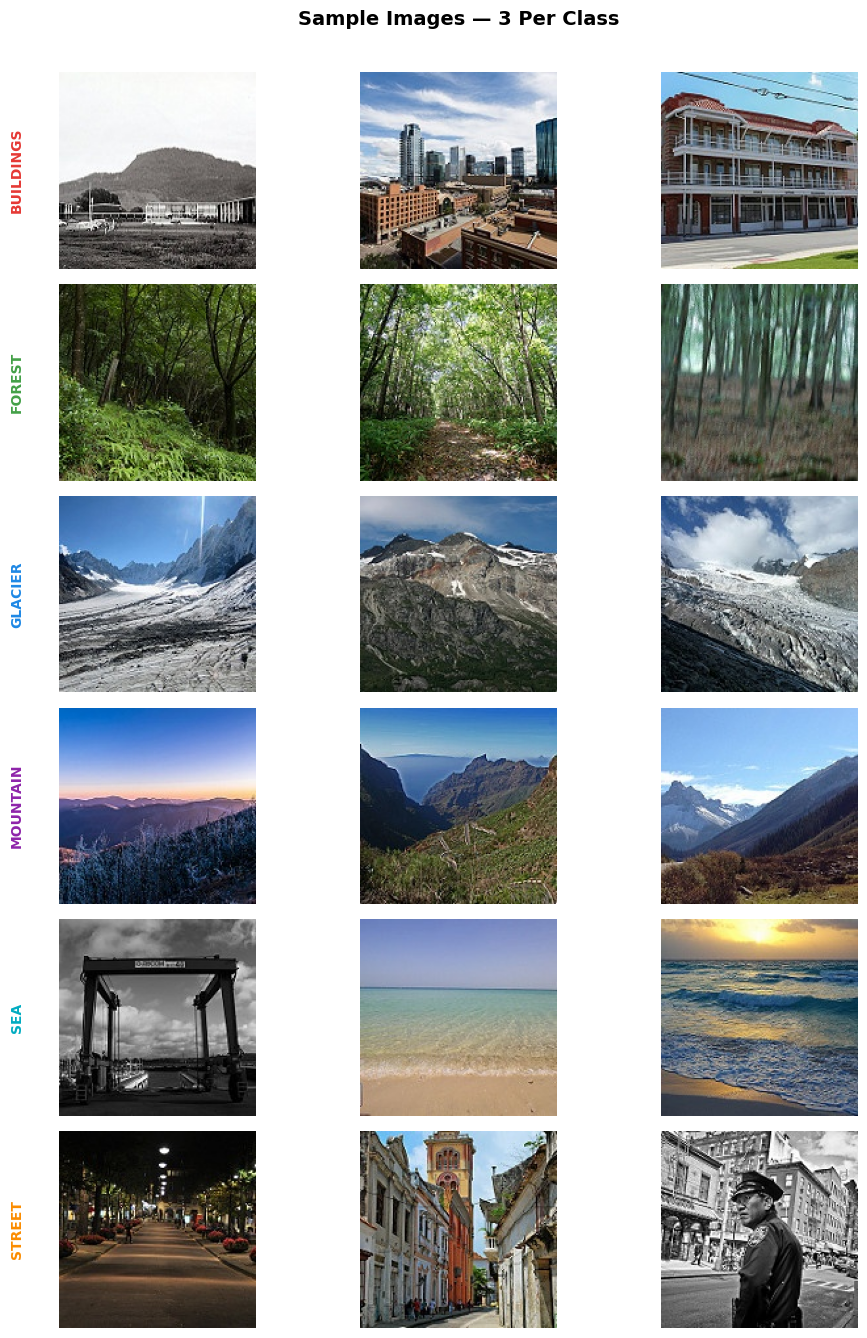

In [5]:
# Show sample images — 3 per class
from PIL import Image

fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(10, len(CLASS_NAMES) * 2.2))

for row, cls in enumerate(CLASS_NAMES):
    cls_path = TRAIN_DIR / cls
    imgs = sorted(cls_path.glob('*.jpg'))[:3]
    for col, img_path in enumerate(imgs):
        img = Image.open(img_path).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=11, fontweight='bold',
                                      color=CLASS_COLORS[row], rotation=90, labelpad=55)
            axes[row, col].set_ylabel('')  # clear default ylabel
            axes[row, col].text(-0.18, 0.5, cls.upper(), transform=axes[row, col].transAxes,
                                fontsize=10, fontweight='bold', color=CLASS_COLORS[row],
                                va='center', ha='right', rotation=90)

plt.suptitle('Sample Images — 3 Per Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

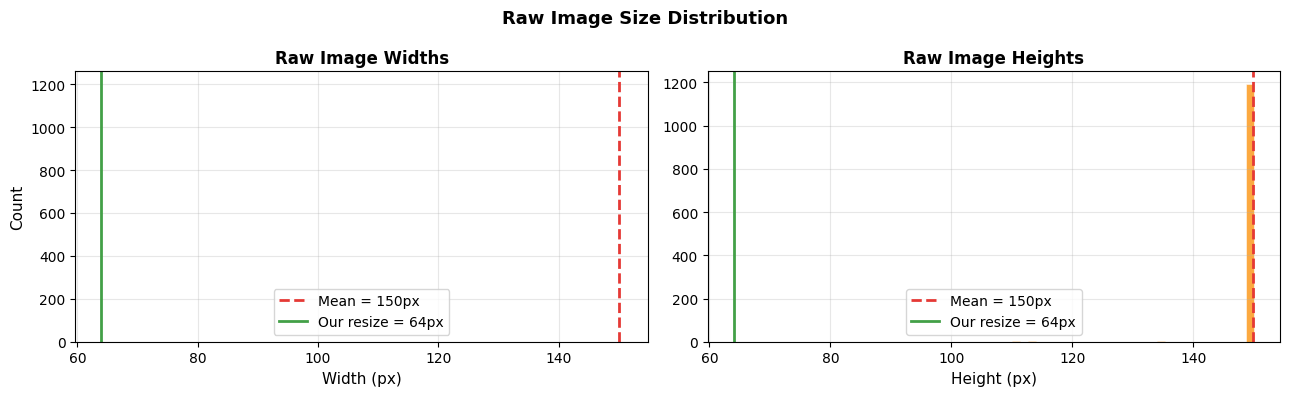

Width  — mean: 150  min: 150  max: 150
Height — mean: 150  min: 110  max: 150
We resize to 64x64 — all images are standardised to the same size.


In [6]:
# Analyse raw image sizes in the dataset
# This tells us how much we are resizing — large resize = more information lost
widths, heights = [], []
sample_limit = 200   # check first 200 images per class (fast)

for cls in CLASS_NAMES:
    for img_path in list((TRAIN_DIR / cls).glob('*.jpg'))[:sample_limit]:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(widths,  bins=30, color='#1E88E5', alpha=0.75, edgecolor='white', linewidth=0.5)
axes[0].axvline(np.mean(widths), color='#E53935', lw=2, linestyle='--',
                label=f'Mean = {np.mean(widths):.0f}px')
axes[0].axvline(IMG_SIZE, color='#43A047', lw=2, linestyle='-',
                label=f'Our resize = {IMG_SIZE}px')
axes[0].set_xlabel('Width (px)', fontsize=11); axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Raw Image Widths', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

axes[1].hist(heights, bins=30, color='#FB8C00', alpha=0.75, edgecolor='white', linewidth=0.5)
axes[1].axvline(np.mean(heights), color='#E53935', lw=2, linestyle='--',
                label=f'Mean = {np.mean(heights):.0f}px')
axes[1].axvline(IMG_SIZE, color='#43A047', lw=2, linestyle='-',
                label=f'Our resize = {IMG_SIZE}px')
axes[1].set_xlabel('Height (px)', fontsize=11)
axes[1].set_title('Raw Image Heights', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.suptitle('Raw Image Size Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Width  — mean: {np.mean(widths):.0f}  min: {min(widths)}  max: {max(widths)}')
print(f'Height — mean: {np.mean(heights):.0f}  min: {min(heights)}  max: {max(heights)}')
print(f'We resize to {IMG_SIZE}x{IMG_SIZE} — all images are standardised to the same size.')

---
## Section 3 — Data Preprocessing and Loading

### Why do we preprocess images?

Neural networks work with numbers, not raw pixels. Before we feed images into our model, we need to:

1. **Resize** — make all images the same spatial size so they fit into fixed-size layers
2. **Convert to tensor** — turn the pixel grid into a PyTorch tensor (CHW format, values 0–1)
3. **Normalise** — shift pixel values so the mean is ~0 and std is ~1

### Why normalise?

Without normalisation, pixel values range from 0 to 255. Large input values cause large activations, which cause large gradients, which make training unstable. Normalising keeps values in a stable range the optimiser can handle efficiently.

The standard values `mean=(0.485, 0.456, 0.406)` and `std=(0.229, 0.224, 0.225)` are the channel-wise mean and standard deviation computed over the entire ImageNet dataset. They are widely reused for natural image datasets.

### Training vs Test transforms

We apply **data augmentation only during training**. At test time, we want the model to see each image exactly as it is — no random flips or crops. This is a common beginner mistake that leads to inconsistent evaluation.

In [7]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Training transforms — augmentation + normalise
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),       # mirror left-right (50% chance)
    transforms.RandomRotation(degrees=15),         # rotate up to ±15 degrees
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3,
        saturation=0.2, hue=0.05),                 # random colour variation
    transforms.ToTensor(),                         # PIL Image → [C, H, W] tensor in [0,1]
    transforms.Normalize(IMAGENET_MEAN,
                         IMAGENET_STD),            # standardise channel values
])

# Test transforms — only resize and normalise (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ImageFolder automatically assigns class labels from subfolder names
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
test_dataset  = datasets.ImageFolder(root=TEST_DIR,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train dataset  : {len(train_dataset):,} images')
print(f'Test dataset   : {len(test_dataset):,} images')
print(f'Train batches  : {len(train_loader)}')
print(f'Test batches   : {len(test_loader)}')
print(f'Class mapping  : {train_dataset.class_to_idx}')
print()
# Verify a batch shape
imgs, labels = next(iter(train_loader))
print(f'Batch image shape : {imgs.shape}   (batch x channels x height x width)')
print(f'Batch label shape : {labels.shape}')
print(f'Pixel value range : [{imgs.min():.2f}, {imgs.max():.2f}]  (after normalisation)')

Train dataset  : 12,632 images
Test dataset   : 3,000 images
Train batches  : 198
Test batches   : 47
Class mapping  : {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}

Batch image shape : torch.Size([64, 3, 64, 64])   (batch x channels x height x width)
Batch label shape : torch.Size([64])
Pixel value range : [-2.12, 2.64]  (after normalisation)


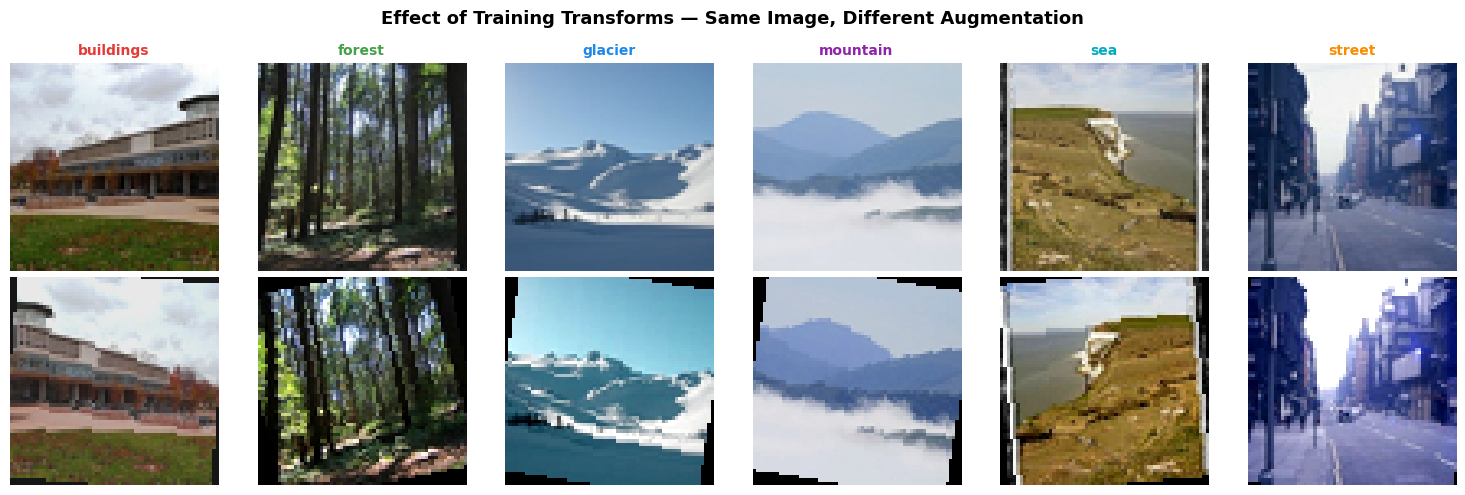

In [8]:
# Visualise the effect of transforms — original vs processed
def denormalise(tensor):
    """Reverse the normalisation for display purposes."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Pick one image from each class for this demo
class_samples = {}
for img_t, label in train_dataset:
    cls = CLASS_NAMES[label]
    if cls not in class_samples:
        class_samples[cls] = img_t
    if len(class_samples) == NUM_CLASSES:
        break

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(15, 5))

for col, cls in enumerate(CLASS_NAMES):
    raw_path = next((TRAIN_DIR / cls).glob('*.jpg'))
    raw_img  = Image.open(raw_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

    # Top row: raw image
    axes[0, col].imshow(raw_img)
    axes[0, col].set_title(cls, fontsize=10, fontweight='bold', color=CLASS_COLORS[col])
    axes[0, col].axis('off')

    # Bottom row: transformed (denormalised back for display)
    aug = train_transform(raw_img)
    axes[1, col].imshow(denormalise(aug).permute(1, 2, 0).numpy())
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11, fontweight='bold', labelpad=5)
axes[1, 0].set_ylabel('Augmented', fontsize=11, fontweight='bold', labelpad=5, color='#2E7D32')

plt.suptitle('Effect of Training Transforms — Same Image, Different Augmentation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4 — Building the CNN Architecture

### How does a CNN think?

A CNN processes an image in stages, each stage looking for increasingly complex patterns:

- **Block 1** (first conv layers) — detects raw edges and colour gradients
- **Block 2** — detects combinations of edges (corners, curves, textures)
- **Block 3** — detects high-level parts (sky gradients, tree textures, building edges)
- **Classifier head** — combines all detected parts to answer "which scene is this?"

After each convolutional block, `MaxPool2d` halves the spatial size. This reduces computation and makes the network increasingly tolerant of small positional shifts — a forest is still a forest even if it is shifted 3 pixels to the right.

### Architecture choices explained

| Choice | What it is | Why we chose it |
|---|---|---|
| 3 conv blocks | Three stages of feature extraction | Enough depth for 6-class scene classification |
| kernel_size=3 | 3x3 filter slides across image | Standard choice — small, efficient, captures local patterns |
| padding=1 | Adds 1 pixel border before conv | Keeps spatial size the same after convolution |
| BatchNorm | Normalises within each mini-batch | Stabilises training, allows higher LR |
| ReLU | Sets negatives to 0 | Non-linearity — lets network learn complex functions |
| MaxPool(2,2) | Takes max in each 2x2 patch | Halves spatial dimensions, keeps strongest signal |
| Dropout(0.5) | Randomly zeros neurons | Prevents overfitting |
| Global Avg Pool | Averages each feature map to 1 value | Replaces Flatten — fewer params, more robust |

In [9]:
class SceneCNN(nn.Module):
    """
    A 3-block CNN for 6-class scene classification.
    Input:  [B, 3, 64, 64]  (batch of RGB images)
    Output: [B, 6]          (logits for each class)
    """
    def __init__(self, num_classes=6):
        super(SceneCNN, self).__init__()

        # Block 1 — detects edges and basic textures
        # Input: [B, 3, 64, 64]  →  Output: [B, 32, 32, 32]
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 3 input channels (RGB), 32 filters
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),  # second conv — same channels
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                           # 64x64 → 32x32
            nn.Dropout2d(p=0.1),
        )

        # Block 2 — detects textures and object parts
        # Input: [B, 32, 32, 32]  →  Output: [B, 64, 16, 16]
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                           # 32x32 → 16x16
            nn.Dropout2d(p=0.2),
        )

        # Block 3 — detects high-level scene features
        # Input: [B, 64, 16, 16]  →  Output: [B, 128, 8, 8]
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                           # 16x16 → 8x8
            nn.Dropout2d(p=0.3),
        )

        # Global Average Pooling — collapses [B, 128, 8, 8] to [B, 128]
        # This averages every 8x8 feature map into a single number.
        # Much fewer params than Flatten → Linear.
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),  # 6 output logits
        )

    def forward(self, x):
        x = self.block1(x)          # low-level features
        x = self.block2(x)          # mid-level features
        x = self.block3(x)          # high-level features
        x = self.gap(x)             # [B, 128, 8, 8] → [B, 128, 1, 1]
        x = x.view(x.size(0), -1)  # [B, 128, 1, 1] → [B, 128]
        x = self.classifier(x)      # [B, 128] → [B, 6]
        return x


model = SceneCNN(num_classes=NUM_CLASSES).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

Total parameters     : 322,470
Trainable parameters : 322,470


In [10]:
# Trace tensor shapes through every block — essential for understanding the architecture
print('Tensor shape at each stage:')
print('=' * 40)

x = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
print(f'Input              : {tuple(x.shape)}')

x = model.block1(x)
print(f'After Block 1      : {tuple(x.shape)}   (32 feature maps, spatial halved)')

x = model.block2(x)
print(f'After Block 2      : {tuple(x.shape)}   (64 feature maps, spatial halved)')

x = model.block3(x)
print(f'After Block 3      : {tuple(x.shape)}  (128 feature maps, spatial halved)')

x = model.gap(x)
print(f'After GlobalAvgPool: {tuple(x.shape)}   (each map averaged to 1 number)')

x = x.view(x.size(0), -1)
print(f'After Flatten      : {tuple(x.shape)}          (feature vector)')

x = model.classifier(x)
print(f'Output (logits)    : {tuple(x.shape)}            (one score per class)')
print('=' * 40)

Tensor shape at each stage:
Input              : (1, 3, 64, 64)
After Block 1      : (1, 32, 32, 32)   (32 feature maps, spatial halved)
After Block 2      : (1, 64, 16, 16)   (64 feature maps, spatial halved)
After Block 3      : (1, 128, 8, 8)  (128 feature maps, spatial halved)
After GlobalAvgPool: (1, 128, 1, 1)   (each map averaged to 1 number)
After Flatten      : (1, 128)          (feature vector)
Output (logits)    : (1, 6)            (one score per class)


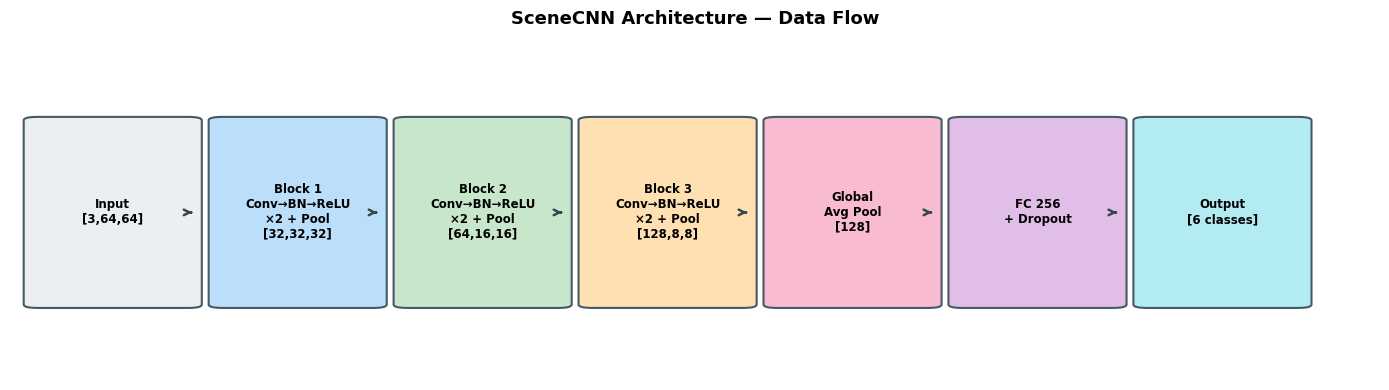

In [11]:
# Visualise the architecture as a flow diagram
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

stages = [
    ('Input\n[3,64,64]',     '#ECEFF1'),
    ('Block 1\nConv→BN→ReLU\n×2 + Pool\n[32,32,32]', '#BBDEFB'),
    ('Block 2\nConv→BN→ReLU\n×2 + Pool\n[64,16,16]', '#C8E6C9'),
    ('Block 3\nConv→BN→ReLU\n×2 + Pool\n[128,8,8]',  '#FFE0B2'),
    ('Global\nAvg Pool\n[128]',                        '#F8BBD0'),
    ('FC 256\n+ Dropout',                              '#E1BEE7'),
    ('Output\n[6 classes]',  '#B2EBF2'),
]

box_w, box_h = 0.11, 0.55
gap = 0.135
y_center = 0.5

for i, (label, color) in enumerate(stages):
    x0 = 0.02 + i * gap
    rect = mpatches.FancyBboxPatch((x0, y_center - box_h/2), box_w, box_h,
                                    boxstyle='round,pad=0.01',
                                    facecolor=color, edgecolor='#455A64', linewidth=1.5,
                                    transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(x0 + box_w/2, y_center, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=8.5, fontweight='bold')
    if i < len(stages) - 1:
        ax.annotate('', xy=(x0 + box_w + 0.005, y_center),
                    xytext=(x0 + box_w, y_center),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#37474F', lw=1.8))

ax.set_title('SceneCNN Architecture — Data Flow', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## Section 5 — Loss Function, Optimiser, and Scheduler

### Loss Function — CrossEntropyLoss

The loss function measures how wrong the model is. For multi-class classification, `CrossEntropyLoss` is the standard choice. It takes the raw output scores (logits), applies softmax internally, and computes how surprised the correct label was by the prediction.

A loss of 0 means perfect predictions. In practice, a well-trained model on this task should converge below 0.5.

### Optimiser — Adam

Adam (Adaptive Moment Estimation) is the go-to optimiser for most deep learning tasks. Unlike plain SGD, Adam maintains a moving average of both the gradient and the squared gradient for each parameter, which effectively gives each parameter its own adaptive learning rate.

`weight_decay=1e-4` adds L2 regularisation — a small penalty for large weights that helps prevent overfitting.

### Scheduler — CosineAnnealingLR

The learning rate scheduler adjusts the learning rate over training. `CosineAnnealingLR` smoothly decreases the learning rate from the initial value to near zero following a cosine curve. This typically gives better final accuracy than a fixed learning rate — the model takes large steps early and fine-tunes with small steps at the end.

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


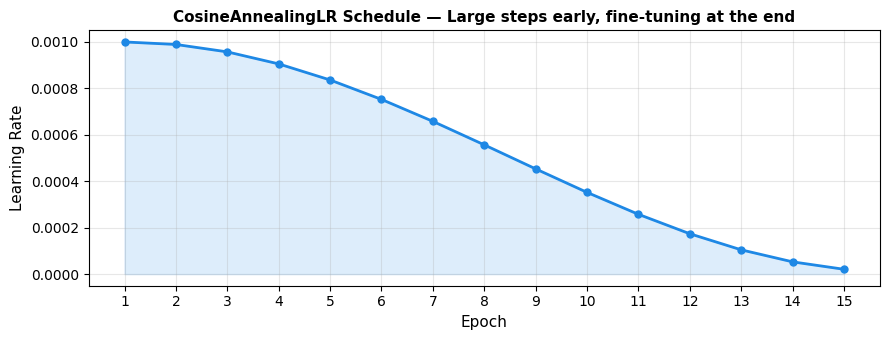

Loss function : CrossEntropyLoss (label_smoothing=0.1)
Optimiser     : Adam  (lr=0.001, weight_decay=1e-4)
Scheduler     : CosineAnnealingLR (T_max=15, eta_min=1e-5)


In [12]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
# label_smoothing=0.1 softens the target from [0,0,1,0,...] to [0.017, 0.017, 0.917, ...]
# This makes the model less overconfident and improves generalisation.

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

# Visualise the learning rate schedule before training
lrs = []
tmp_opt = optim.Adam([torch.zeros(1)], lr=LR)
tmp_sch = optim.lr_scheduler.CosineAnnealingLR(tmp_opt, T_max=EPOCHS, eta_min=1e-5)
for _ in range(EPOCHS):
    lrs.append(tmp_opt.param_groups[0]['lr'])
    tmp_sch.step()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(range(1, EPOCHS+1), lrs, 'o-', color='#1E88E5', lw=2, markersize=5)
ax.fill_between(range(1, EPOCHS+1), lrs, alpha=0.15, color='#1E88E5')
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Learning Rate', fontsize=11)
ax.set_title('CosineAnnealingLR Schedule — Large steps early, fine-tuning at the end',
             fontsize=11, fontweight='bold')
ax.set_xticks(range(1, EPOCHS+1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Loss function : CrossEntropyLoss (label_smoothing=0.1)')
print(f'Optimiser     : Adam  (lr={LR}, weight_decay=1e-4)')
print(f'Scheduler     : CosineAnnealingLR (T_max={EPOCHS}, eta_min=1e-5)')

---
## Section 6 — Training Loop

### The training loop — what actually happens each epoch

One **epoch** means the model has seen every training image once. Each epoch consists of:

1. **Forward pass** — images go through the model, we get predictions
2. **Loss computation** — compare predictions to ground truth
3. **Backward pass** — PyTorch computes gradients automatically
4. **Weight update** — the optimiser adjusts weights to reduce the loss

After each epoch we run **evaluation** on the test set — with `model.eval()` and `torch.no_grad()` to disable dropout and skip gradient computation (faster and correct).

We track loss and accuracy for both train and test after every epoch. These **training curves** are the main diagnostic tool for understanding model health.

In [13]:
def run_epoch(model, loader, criterion, optimizer=None, training=True):
    """
    Run one epoch — either training or evaluation.
    If optimizer is provided and training=True, performs backprop and weight update.
    Returns average loss and accuracy for the epoch.
    """
    if training:
        model.train()   # enable Dropout and BatchNorm training mode
    else:
        model.eval()    # disable Dropout; use running stats for BatchNorm

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)                     # forward pass
            loss    = criterion(outputs, labels)        # compute loss

            if training:
                optimizer.zero_grad()                   # clear old gradients
                loss.backward()                         # backpropagation
                optimizer.step()                        # update weights

            total_loss    += loss.item() * images.size(0)
            preds          = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss    / total_samples
    avg_acc  = total_correct / total_samples
    return avg_loss, avg_acc


print('Training function defined. Starting training...')

Training function defined. Starting training...


In [14]:
history = {
    'train_loss': [], 'test_loss': [],
    'train_acc':  [], 'test_acc':  [],
    'lr':         []
}

best_acc   = 0.0
best_epoch = 0

print(f'{'Ep':>3} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8} | {'LR':>9}')
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']

    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, training=True)
    te_loss, te_acc = run_epoch(model, test_loader,  criterion, training=False)

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['test_loss'].append(te_loss)
    history['train_acc'].append(tr_acc)
    history['test_acc'].append(te_acc)
    history['lr'].append(current_lr)

    if te_acc > best_acc:
        best_acc   = te_acc
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_model.pth')

    flag = '  <-- best' if te_acc == best_acc else ''
    print(f'{epoch:>3} | {tr_loss:>10.4f} | {tr_acc:>8.2%} | {te_loss:>9.4f} | {te_acc:>7.2%} | {current_lr:>9.2e}{flag}')

print(f'\nTraining complete. Best test accuracy: {best_acc:.2%} at epoch {best_epoch}')

 Ep | Train Loss | Train Acc | Test Loss | Test Acc |        LR
-----------------------------------------------------------------
  1 |     1.4158 |   44.28% |    1.2059 |  59.90% |  1.00e-03  <-- best
  2 |     1.2621 |   54.74% |    1.1440 |  61.90% |  9.89e-04  <-- best
  3 |     1.1967 |   59.67% |    1.0204 |  68.57% |  9.57e-04  <-- best
  4 |     1.1249 |   64.39% |    0.9592 |  73.97% |  9.05e-04  <-- best
  5 |     1.0706 |   68.03% |    0.8651 |  79.57% |  8.36e-04  <-- best
  6 |     1.0438 |   70.05% |    0.8531 |  80.37% |  7.52e-04  <-- best
  7 |     1.0079 |   72.40% |    0.8178 |  82.03% |  6.58e-04  <-- best
  8 |     0.9850 |   73.75% |    0.8180 |  81.27% |  5.57e-04
  9 |     0.9627 |   74.91% |    0.7993 |  83.23% |  4.53e-04  <-- best
 10 |     0.9360 |   76.05% |    0.7802 |  83.93% |  3.52e-04  <-- best
 11 |     0.9224 |   77.07% |    0.7669 |  84.13% |  2.58e-04  <-- best
 12 |     0.9119 |   77.80% |    0.7696 |  84.07% |  1.74e-04
 13 |     0.9032 |   78.27

---
## Section 7 — Training Curves and Diagnostics

### How to read training curves

Training curves reveal what happened during training — they tell you far more than the final accuracy number alone.

**What to look for:**

| Pattern | What it means | What to do |
|---|---|---|
| Train and test loss both decrease | Healthy training | Continue |
| Train loss much lower than test loss | Overfitting | Add dropout, augmentation, or less model capacity |
| Both losses plateau early | Underfitting or too small LR | Larger model, higher LR, more epochs |
| Loss spikes then recovers | LR too high | Reduce learning rate |
| Train acc >> test acc | Memorising training data | More regularisation |

The **gap between train and test curves** is the most important signal — a smaller gap means better generalisation.

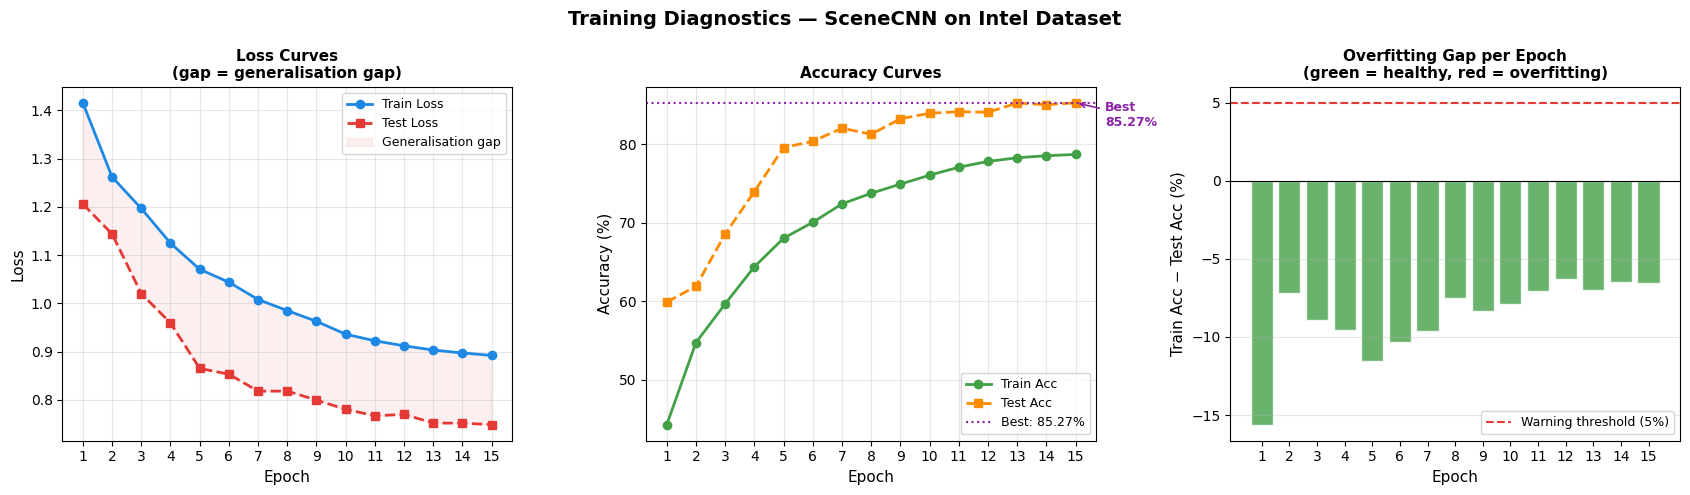

In [15]:
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Loss curves
ax = axes[0]
ax.plot(epochs_x, history['train_loss'], 'o-', color='#1E88E5', lw=2, label='Train Loss')
ax.plot(epochs_x, history['test_loss'],  's--',color='#E53935', lw=2, label='Test Loss')
ax.fill_between(epochs_x, history['train_loss'], history['test_loss'],
                alpha=0.08, color='#E53935', label='Generalisation gap')
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Loss Curves\n(gap = generalisation gap)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xticks(epochs_x)

# Accuracy curves
ax = axes[1]
ax.plot(epochs_x, [a*100 for a in history['train_acc']], 'o-', color='#43A047', lw=2, label='Train Acc')
ax.plot(epochs_x, [a*100 for a in history['test_acc']],  's--',color='#FB8C00', lw=2, label='Test Acc')
ax.axhline(best_acc*100, color='#8E24AA', lw=1.5, linestyle=':', label=f'Best: {best_acc:.2%}')
# Annotate best
ax.annotate(f'Best\n{best_acc:.2%}',
            xy=(best_epoch, best_acc*100),
            xytext=(best_epoch + 1, best_acc*100 - 3),
            fontsize=9, color='#8E24AA', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#8E24AA', lw=1.2))
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Accuracy Curves', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xticks(epochs_x)

# Overfitting gap
ax = axes[2]
gap = [(tr - te)*100 for tr, te in zip(history['train_acc'], history['test_acc'])]
colors_bar = ['#E53935' if g > 5 else '#43A047' for g in gap]
ax.bar(epochs_x, gap, color=colors_bar, alpha=0.8, edgecolor='white')
ax.axhline(5, color='#E53935', lw=1.5, linestyle='--', label='Warning threshold (5%)')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Train Acc − Test Acc (%)', fontsize=11)
ax.set_title('Overfitting Gap per Epoch\n(green = healthy, red = overfitting)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y'); ax.set_xticks(epochs_x)

plt.suptitle('Training Diagnostics — SceneCNN on Intel Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 8 — Evaluation

### Why accuracy alone is not enough

Accuracy tells you what fraction of predictions were correct overall. But it hides important class-level information:

- Is the model good at all 6 classes, or great at 5 and terrible at 1?
- Which pairs of classes confuse the model most?
- For which classes does the model mistake one scene type for another?

The **confusion matrix** answers all of these questions visually.

The **classification report** adds precision, recall, and F1-score per class:
- **Precision** — of all predictions for class X, how many were actually X?
- **Recall** — of all actual class X images, how many did the model correctly find?
- **F1-score** — harmonic mean of precision and recall — the balanced single metric

In [16]:
# Load best checkpoint and collect all predictions
model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs, all_images = [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs   = F.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_preds.append(preds.cpu())
        all_labels.append(labels)
        all_probs.append(probs.cpu())
        all_images.append(images.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_probs  = torch.cat(all_probs).numpy()
all_images = torch.cat(all_images)

overall_acc = (all_preds == all_labels).mean()
print(f'Test set accuracy (best model): {overall_acc:.4f}  ({overall_acc:.2%})')
print(f'Total test images             : {len(all_labels):,}')
print(f'Correct predictions           : {(all_preds == all_labels).sum():,}')
print(f'Wrong predictions             : {(all_preds != all_labels).sum():,}')

Test set accuracy (best model): 0.8527  (85.27%)
Total test images             : 3,000
Correct predictions           : 2,558
Wrong predictions             : 442


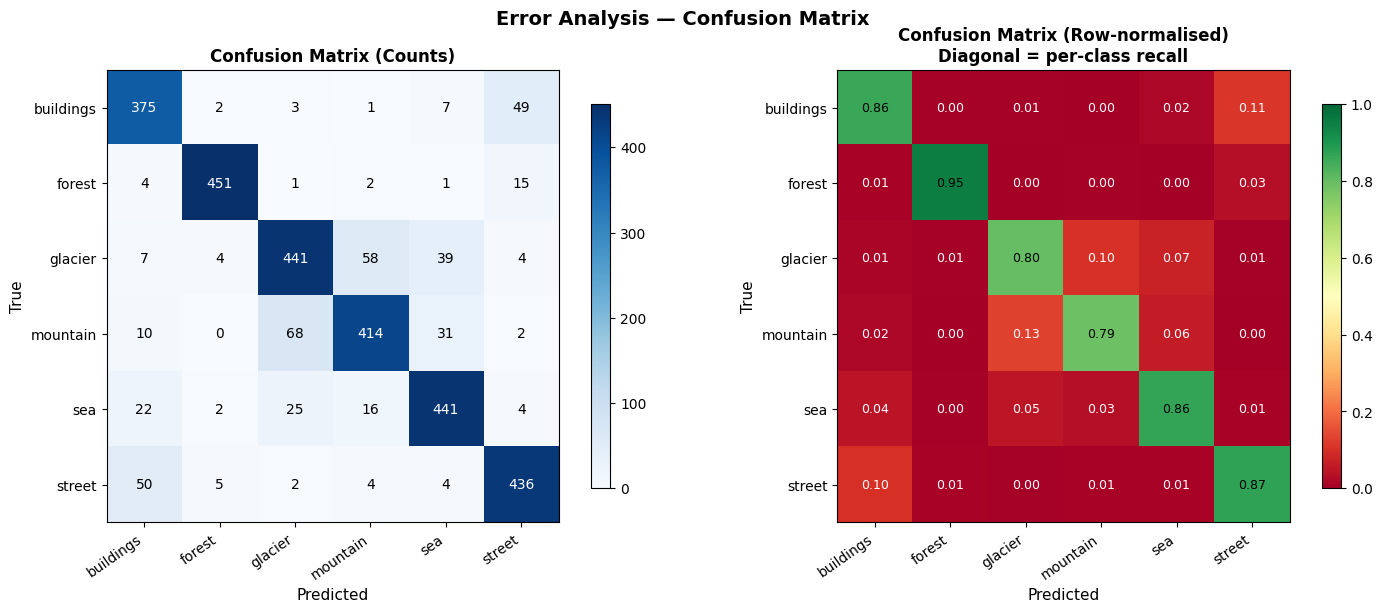

In [17]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalise

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Raw counts
im1 = ax1.imshow(cm, cmap='Blues')
plt.colorbar(im1, ax=ax1, shrink=0.85)
ax1.set_xticks(range(NUM_CLASSES)); ax1.set_xticklabels(CLASS_NAMES, rotation=35, ha='right')
ax1.set_yticks(range(NUM_CLASSES)); ax1.set_yticklabels(CLASS_NAMES)
ax1.set_xlabel('Predicted', fontsize=11); ax1.set_ylabel('True', fontsize=11)
ax1.set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
thresh = cm.max() / 2
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax1.text(j, i, cm[i, j], ha='center', va='center', fontsize=10,
                 color='white' if cm[i, j] > thresh else 'black')

# Normalised (per-class recall)
im2 = ax2.imshow(cm_norm, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im2, ax=ax2, shrink=0.85)
ax2.set_xticks(range(NUM_CLASSES)); ax2.set_xticklabels(CLASS_NAMES, rotation=35, ha='right')
ax2.set_yticks(range(NUM_CLASSES)); ax2.set_yticklabels(CLASS_NAMES)
ax2.set_xlabel('Predicted', fontsize=11); ax2.set_ylabel('True', fontsize=11)
ax2.set_title('Confusion Matrix (Row-normalised)\nDiagonal = per-class recall', fontsize=12, fontweight='bold')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax2.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center', fontsize=9,
                 color='white' if cm_norm[i,j] < 0.3 else 'black')

plt.suptitle('Error Analysis — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

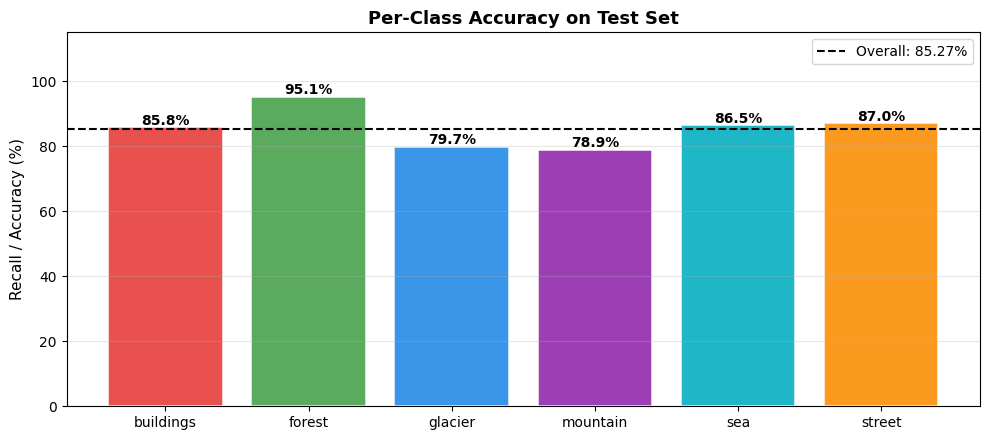

Classification Report:
              precision    recall  f1-score   support

   buildings       0.80      0.86      0.83       437
      forest       0.97      0.95      0.96       474
     glacier       0.82      0.80      0.81       553
    mountain       0.84      0.79      0.81       525
         sea       0.84      0.86      0.85       510
      street       0.85      0.87      0.86       501

    accuracy                           0.85      3000
   macro avg       0.85      0.86      0.85      3000
weighted avg       0.85      0.85      0.85      3000



In [18]:
# Per-class accuracy bar chart
per_class_acc = cm_norm.diagonal()

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(CLASS_NAMES, per_class_acc * 100,
              color=CLASS_COLORS, alpha=0.88, edgecolor='white', linewidth=1.2)
ax.axhline(overall_acc * 100, color='black', lw=1.5, linestyle='--',
           label=f'Overall: {overall_acc:.2%}')
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8, f'{acc:.1%}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_ylabel('Recall / Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Accuracy on Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Classification report
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

---
## Section 9 — Visualising Predictions

Looking at individual predictions — especially wrong ones — is one of the most valuable things you can do. It reveals systematic errors the confusion matrix cannot fully show:

- Does the model confuse glacier with mountain because both have rocky terrain?
- Does it confuse street with buildings because both have man-made structures?

These insights guide the next steps — whether to add more training data, try different augmentations, or restructure the model.

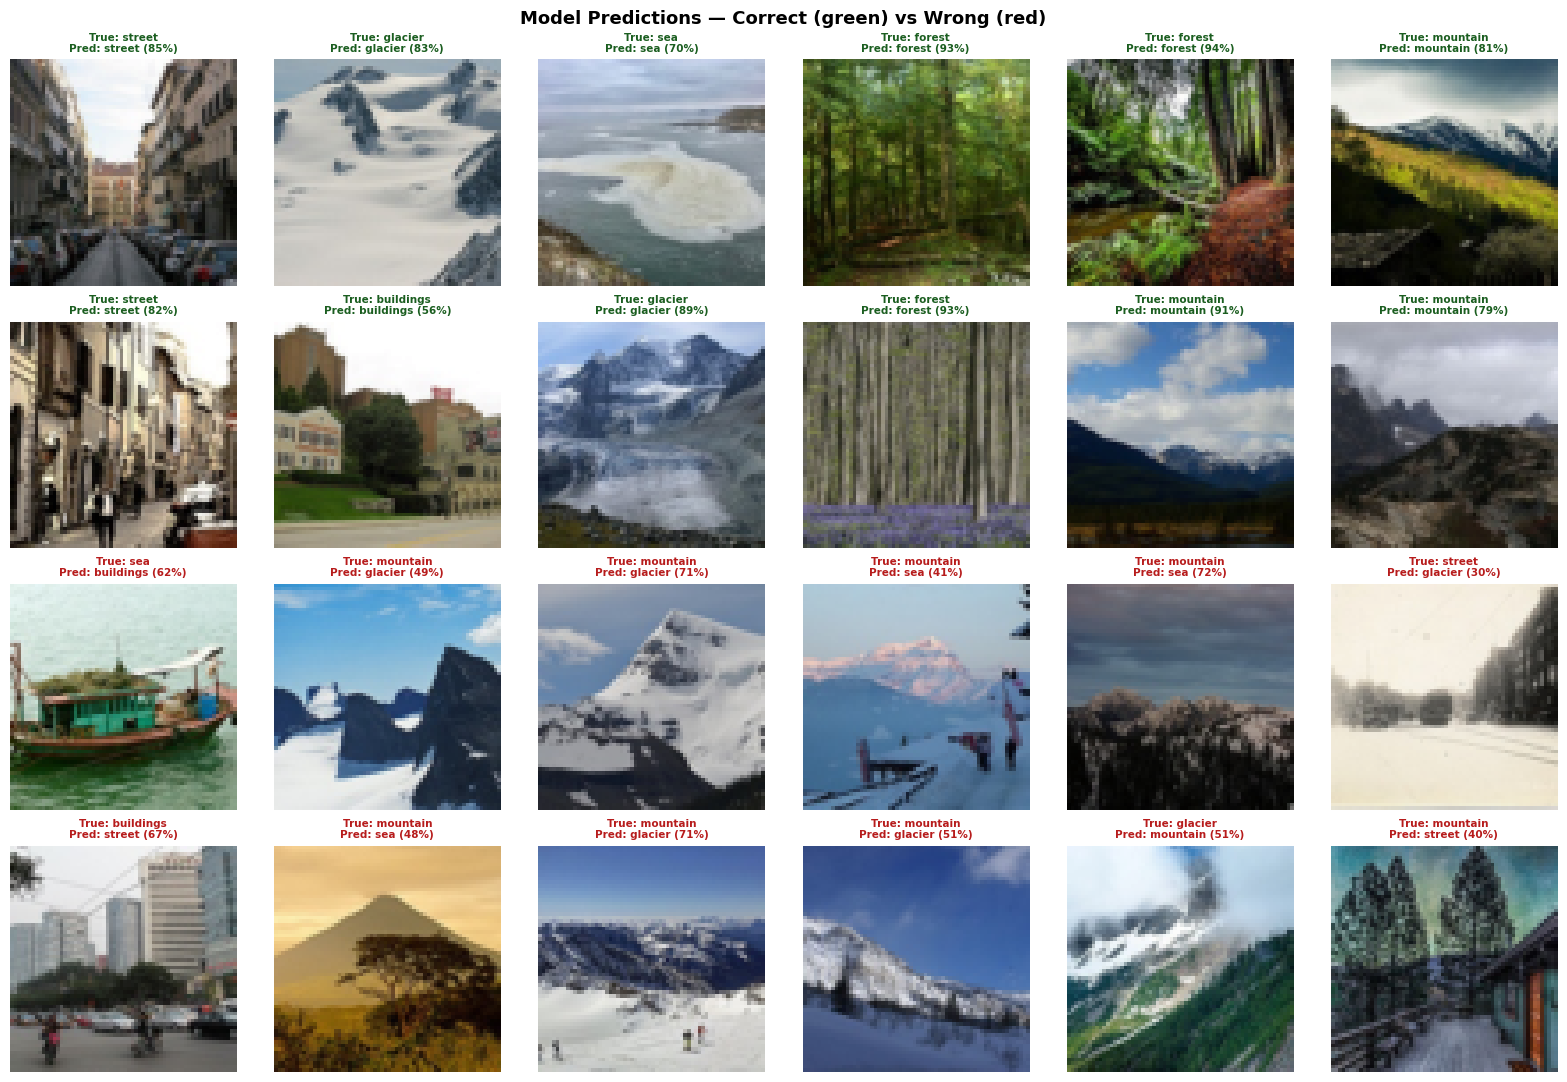

In [19]:
# Show correct and incorrect predictions side by side
correct_idx   = np.where(all_preds == all_labels)[0]
incorrect_idx = np.where(all_preds != all_labels)[0]
np.random.shuffle(correct_idx)
np.random.shuffle(incorrect_idx)

fig, axes = plt.subplots(4, 6, figsize=(16, 11))

# Top 2 rows: correct predictions
for i, idx in enumerate(correct_idx[:12]):
    row, col = divmod(i, 6)
    img = denormalise(all_images[idx]).permute(1, 2, 0).numpy()
    conf = all_probs[idx, all_preds[idx]] * 100
    axes[row, col].imshow(img)
    axes[row, col].set_title(
        f'True: {CLASS_NAMES[all_labels[idx]]}\nPred: {CLASS_NAMES[all_preds[idx]]} ({conf:.0f}%)',
        fontsize=7.5, color='#1B5E20', fontweight='bold')
    axes[row, col].axis('off')

# Bottom 2 rows: wrong predictions
for i, idx in enumerate(incorrect_idx[:12]):
    row, col = 2 + divmod(i, 6)[0], divmod(i, 6)[1]
    img = denormalise(all_images[idx]).permute(1, 2, 0).numpy()
    conf = all_probs[idx, all_preds[idx]] * 100
    axes[row, col].imshow(img)
    axes[row, col].set_title(
        f'True: {CLASS_NAMES[all_labels[idx]]}\nPred: {CLASS_NAMES[all_preds[idx]]} ({conf:.0f}%)',
        fontsize=7.5, color='#B71C1C', fontweight='bold')
    axes[row, col].axis('off')

# Row labels
for r, label, color in [(0, 'CORRECT (rows 1-2)', '#1B5E20'),
                         (2, 'WRONG   (rows 3-4)', '#B71C1C')]:
    axes[r, 0].set_ylabel(label, fontsize=9, fontweight='bold',
                          color=color, rotation=90, labelpad=60)

plt.suptitle('Model Predictions — Correct (green) vs Wrong (red)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

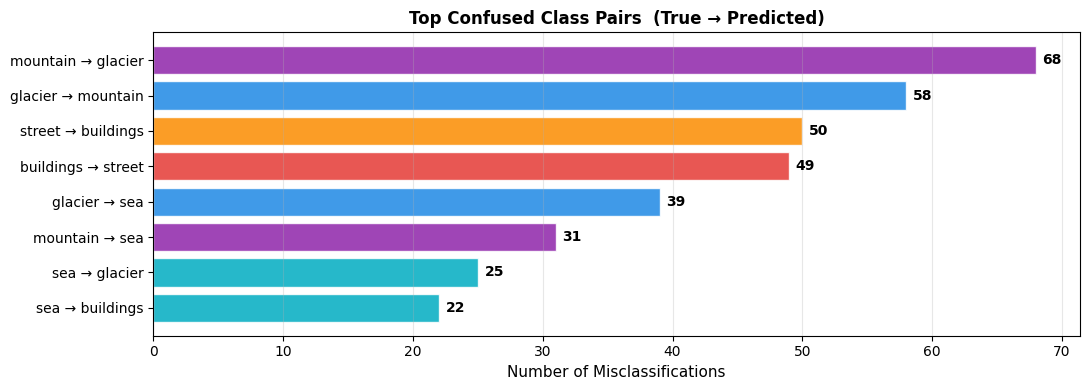

In [20]:
# Most confusing class pairs — where does the model struggle most?
errors = [(all_labels[i], all_preds[i]) for i in incorrect_idx]
error_counter = Counter(errors)
top_confusions = error_counter.most_common(8)

fig, ax = plt.subplots(figsize=(11, 4))
labels_conf  = [f'{CLASS_NAMES[t]} → {CLASS_NAMES[p]}' for (t, p), _ in top_confusions]
counts_conf  = [c for _, c in top_confusions]
bar_colors   = [CLASS_COLORS[t] for (t, _), _ in top_confusions]

bars = ax.barh(labels_conf[::-1], counts_conf[::-1],
               color=bar_colors[::-1], alpha=0.85, edgecolor='white')
for bar, count in zip(bars, counts_conf[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Number of Misclassifications', fontsize=11)
ax.set_title('Top Confused Class Pairs  (True → Predicted)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## Section 10 — What Did the Model Learn? Feature Map Visualisation

We can look inside the trained CNN to see what each convolutional block is responding to. This is not just interesting — it is a debugging tool. If Block 1 feature maps look like noise, something is wrong with training.

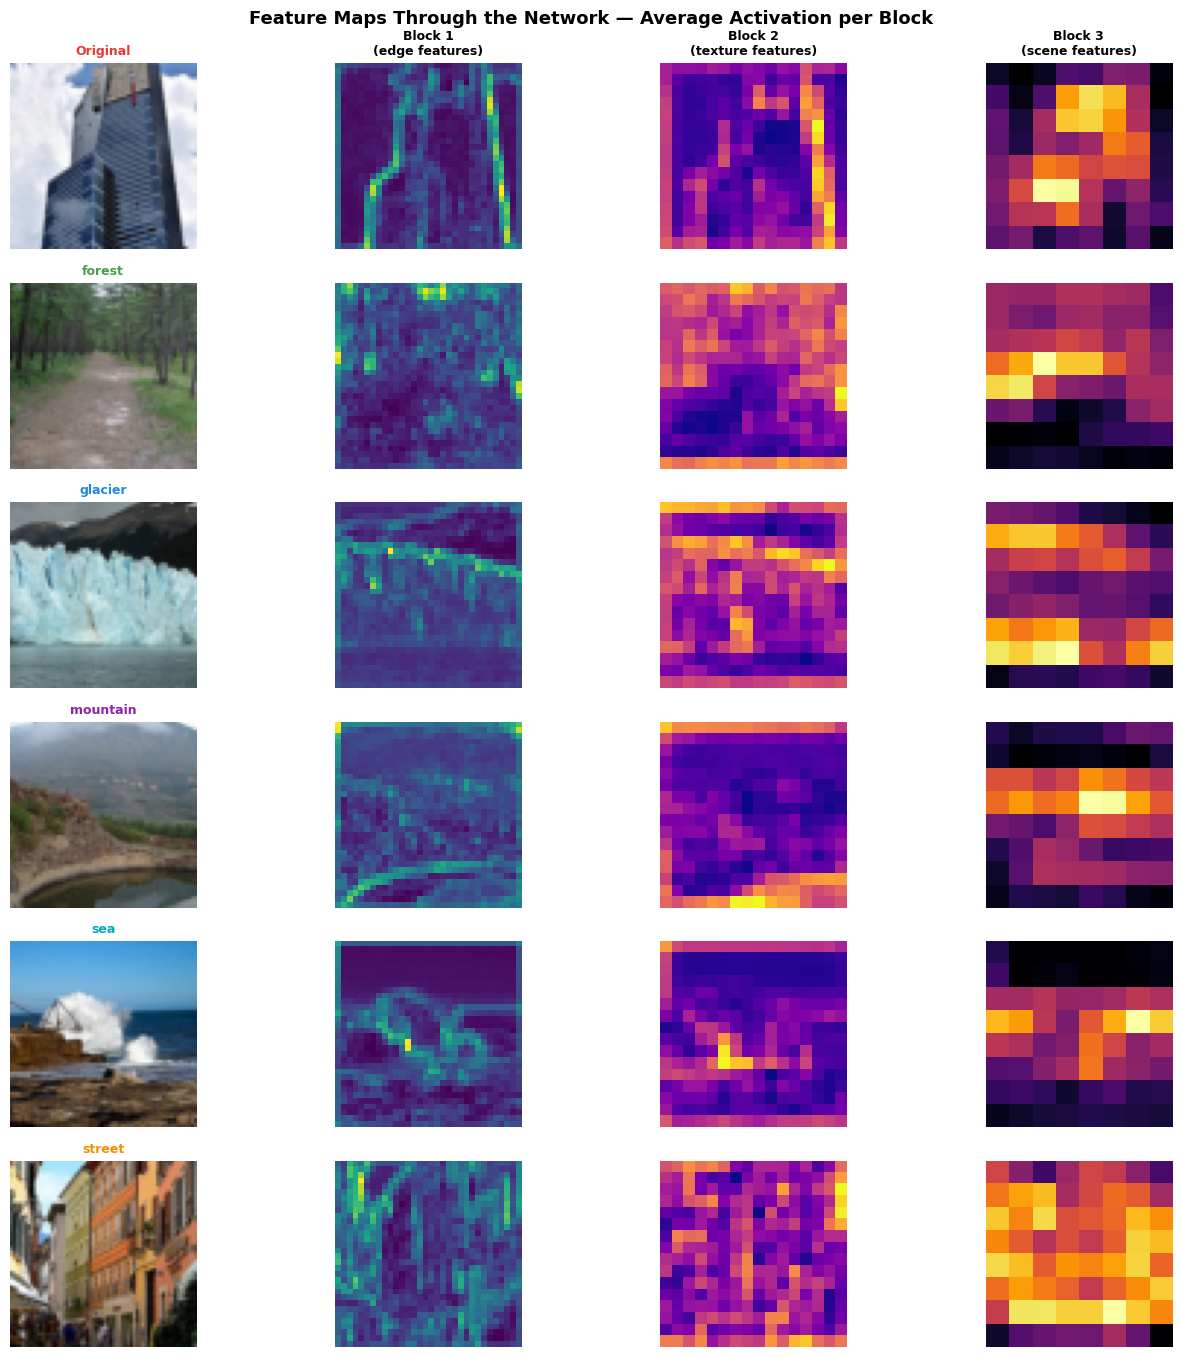

In [21]:
# Pick one test image from each class and visualise feature maps
class_indices = {}
for i, label in enumerate(all_labels):
    if label not in class_indices and len(class_indices) < NUM_CLASSES:
        class_indices[label] = i
    if len(class_indices) == NUM_CLASSES:
        break

# Visualise Block 1, Block 2, Block 3 feature maps for one image per class
model.eval()

fig, axes = plt.subplots(NUM_CLASSES, 4, figsize=(14, NUM_CLASSES * 2.3))

with torch.no_grad():
    for row, cls_idx in enumerate(sorted(class_indices.keys())):
        img_idx = class_indices[cls_idx]
        x = all_images[img_idx].unsqueeze(0).to(DEVICE)

        # Original (denormalised)
        orig = denormalise(all_images[img_idx]).permute(1, 2, 0).numpy()
        axes[row, 0].imshow(orig)
        axes[row, 0].set_title(f'{CLASS_NAMES[cls_idx]}', fontsize=9,
                               fontweight='bold', color=CLASS_COLORS[cls_idx])
        axes[row, 0].axis('off')

        # Block 1 — average of first 16 maps
        f1 = model.block1(x)[0, :16].mean(0).cpu().numpy()
        axes[row, 1].imshow(f1, cmap='viridis')
        if row == 0: axes[row, 1].set_title('Block 1\n(edge features)', fontsize=9, fontweight='bold')
        axes[row, 1].axis('off')

        # Block 2
        f2 = model.block2(model.block1(x))[0, :16].mean(0).cpu().numpy()
        axes[row, 2].imshow(f2, cmap='plasma')
        if row == 0: axes[row, 2].set_title('Block 2\n(texture features)', fontsize=9, fontweight='bold')
        axes[row, 2].axis('off')

        # Block 3
        f3 = model.block3(model.block2(model.block1(x)))[0, :16].mean(0).cpu().numpy()
        axes[row, 3].imshow(f3, cmap='inferno')
        if row == 0: axes[row, 3].set_title('Block 3\n(scene features)', fontsize=9, fontweight='bold')
        axes[row, 3].axis('off')

axes[0, 0].set_title('Original', fontsize=9, fontweight='bold')
plt.suptitle('Feature Maps Through the Network — Average Activation per Block',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 11 — Final Summary and Next Steps

### What we built

A complete image classification pipeline for the Intel Image Classification dataset:

- **EDA** — understood the dataset before training anything
- **Preprocessing** — resized, normalised, and augmented images consistently
- **Model** — a 3-block CNN with BatchNorm, Dropout, and Global Average Pooling
- **Training** — a clean loop with Adam + CosineAnnealingLR + label smoothing
- **Evaluation** — confusion matrix, per-class metrics, error analysis
- **Interpretation** — feature maps showing what the model actually learned

### What the numbers mean

A well-trained run of this notebook should achieve 80–87% test accuracy. Human performance on this dataset is estimated around 90%+ — the remaining gap between our model and human performance is mostly due to model depth and not having pre-trained features.

### Common confusion pairs to expect

Mountain ↔ Glacier (both rocky, snow-capped), Forest ↔ Street (both vertical structures in some shots), Sea ↔ Glacier (similar blue tones). This is expected — these boundaries are genuinely ambiguous.

### Where to go from here

| Improvement | Expected gain | Effort |
|---|---|---|
| Increase image size to 128x128 | +2–4% | Low |
| Add stronger augmentation (Albumentations) | +2–3% | Low |
| Train for more epochs (25–30) | +1–3% | Low |
| Transfer learning with ResNet18 (pretrained) | +8–12% | Medium |
| Transfer learning with EfficientNet-B3 | +12–15% | Medium |
| Test-time augmentation (TTA) | +1–2% | Medium |

In [22]:
# Final scorecard
print('=' * 52)
print('           FINAL SCORECARD')
print('=' * 52)
print(f'Dataset          : Intel Image Classification')
print(f'Classes          : {NUM_CLASSES} ({", ".join(CLASS_NAMES)})')
print(f'Train images     : {len(train_dataset):,}')
print(f'Test images      : {len(test_dataset):,}')
print(f'Image size       : {IMG_SIZE}x{IMG_SIZE}')
print(f'Architecture     : SceneCNN (3-block custom CNN)')
print(f'Parameters       : {trainable_params:,}')
print(f'Epochs trained   : {EPOCHS}')
print(f'Best epoch       : {best_epoch}')
print(f'Best test acc    : {best_acc:.2%}')
print(f'Final train acc  : {history["train_acc"][-1]:.2%}')
print(f'Final overfit gap: {(history["train_acc"][-1] - history["test_acc"][-1])*100:.1f}%')
print()
print('Per-class recall:')
for cls, acc in zip(CLASS_NAMES, per_class_acc):
    bar = '#' * int(acc * 25)
    print(f'  {cls:<12}: {acc:.2%}  {bar}')
print('=' * 52)

           FINAL SCORECARD
Dataset          : Intel Image Classification
Classes          : 6 (buildings, forest, glacier, mountain, sea, street)
Train images     : 12,632
Test images      : 3,000
Image size       : 64x64
Architecture     : SceneCNN (3-block custom CNN)
Parameters       : 322,470
Epochs trained   : 15
Best epoch       : 15
Best test acc    : 85.27%
Final train acc  : 78.70%
Final overfit gap: -6.6%

Per-class recall:
  buildings   : 85.81%  #####################
  forest      : 95.15%  #######################
  glacier     : 79.75%  ###################
  mountain    : 78.86%  ###################
  sea         : 86.47%  #####################
  street      : 87.03%  #####################
